<a href="https://colab.research.google.com/github/martynalacha/Computational-Intelligence-Labs/blob/main/PSO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Zadania do samodzielnego wykonania

1.

Proszę, korzystając z algorytmu roju cząstek znaleźć minimum funkcji

$f(x,y)= 2ln(|𝑥+0.2|+0.002)+ln(|y+0.1|+0.001)+ cos(3x)+2sin^2(3xy)+sin^2(y)-x^2-0.5y^2 $

w przedziale $𝑥, 𝑦 ∈ [-1,1]$,  


przy założeniu że rozwiązanie jest reprezentowane przez wektor [𝑥𝑖, 𝑦𝑖].

Proszę zbadać:
- funkcjonowanie algorytmu dla c1=0, c2=2
- funkcjonowanie algorytmu dla c1=2, c2=0 oraz kilku przypadków pośrednich.
- funkcjonowanie algorytmu dla c1 = c2 = 2,2
- funkcjonowanie dla różnych wartości w.


Za każdym razem należy podać średnie wyniki (wartość funkcji przystosowania) oraz odchylenie standardowe dla 10 wywołań algorytmu i przedstawić przykładowe przebiegi algorytmu na wykresach (dla jednego z wywołań).

Należy opisać, który wariant sprawdzał się najlepiej.

2.

Uzyskany najlepszy wynik proszę w miarę możliwości porównać z algorytmem genetycznym – dedykowanym dla optymalizacji tej samej funkcji. Zakładamy użycie takiej samej liczby epok dla obu algorytmów.
Należy porównać czas działania obydwu algorytmów.

Konfiguracja | Średnia wartość | Odchylenie std 
--------------------------------------------------------------------
c1=0, c2=2, w=0.5              | -13.2679        | 2.4456          | 0.027208       
c1=2, c2=0, w=0.5              | -7.1156         | 2.1407          | 0.037970       
c1=1.496, c2=1.496, w=0.5 (balans Clerca) | -17.8607        | 0.7827          | 0.024923       
c1=0.5, c2=2.5, w=0.5 (posredni2) | -14.7449        | 2.2043          | 0.033017       
c1=2.5, c2=0.5, w=0.5 (posredni3) | -18.5279        | 0.0206          | 0.031636       
c1=2.2, c2=2.2, w=0.5          | -17.2527        | 1.2252          | 0.040500       
c1=1.5, c2=1.5, w=0.1 (male w) | -18.5375        | 0.0060          | 0.054043       
c1=1.5, c2=1.5, w=0.3 (srednie-male w) | -18.3760        | 0.4864          | 0.082796       
c1=1.5, c2=1.5, w=0.5 (srodkowe w) | -17.6957        | 2.2153          | 0.127576       
c1=1.5, c2=1.5, w=0.729 (typowe w) | -16.4437        | 1.3626          | 0.134040       

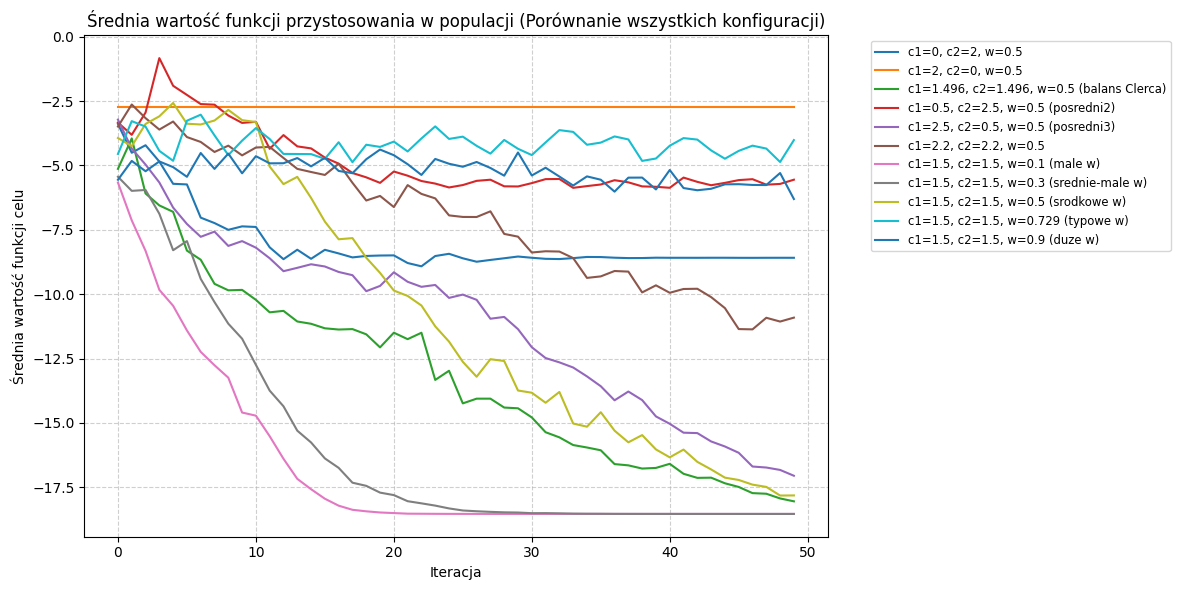

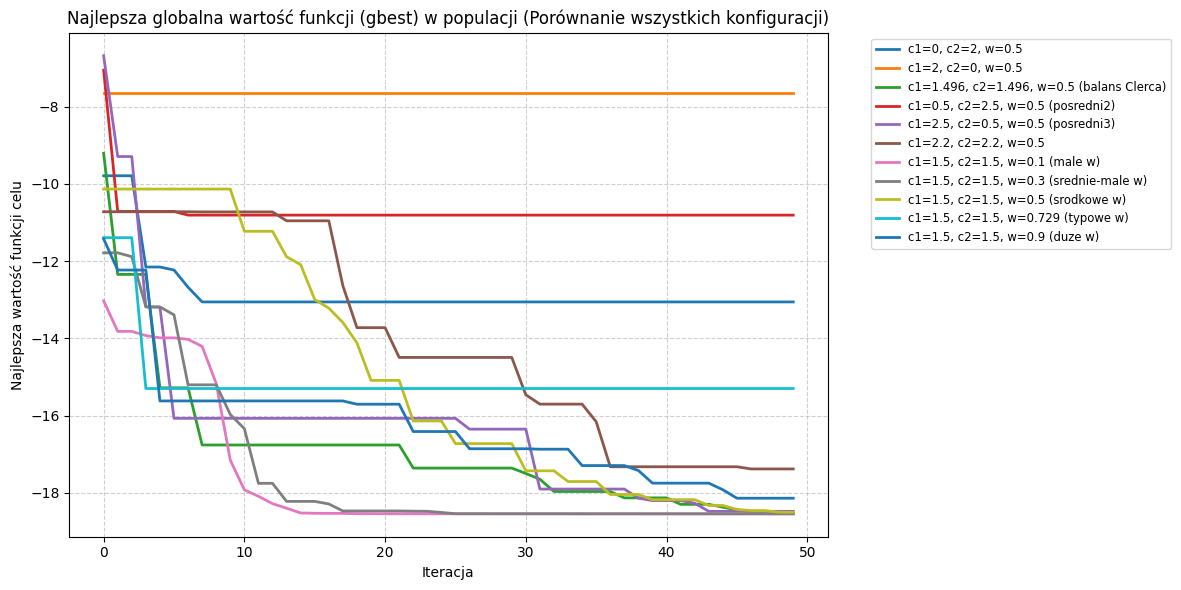

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import time

# Definicja funkcji celu – Rastrigin
def target_function(vector):
  x, y = vector
  term1 = 2 * np.log(np.abs(x + 0.2) + 0.002)
  term2 = np.log(np.abs(y + 0.1) + 0.001)
  term3 = np.cos(3 * x)
  term4 = 2 * (np.sin(3 * x * y) ** 2)
  term5 = np.sin(y) ** 2
  term6 = - (x ** 2) - 0.5 * (y ** 2)

  return term1 + term2 + term3 + term4 + term5 + term6

# Implementacja algorytmu PSO (Particle Swarm Optimization)
def pso(cost_func, dim=2, num_particles=30, max_iter=50, w=0.5, c1=1, c2=2):
    # Inicjalizacja pozycji i prędkości cząstek
    particles = np.random.uniform(-1, 1, (num_particles, dim))
    velocities = np.zeros((num_particles, dim))

    # Inicjalizacja najlepszych znanych pozycji
    best_positions = np.copy(particles)
    best_fitness = np.array([cost_func(p) for p in particles])
    swarm_best_position = best_positions[np.argmin(best_fitness)]
    swarm_best_fitness = np.min(best_fitness)

    # Listy do śledzenia historii optymalizacji
    avgs = []           # średnia wartość funkcji w każdej iteracji
    bests_fitness = []  # najlepsza wartość funkcji w każdej iteracji

    # Główna pętla optymalizacji
    for i in range(max_iter):
        r1 = np.random.rand(num_particles, dim)
        r2 = np.random.rand(num_particles, dim)

        # Aktualizacja prędkości cząstek
        velocities = (
            w * velocities
            + c1 * r1 * (best_positions - particles)
            + c2 * r2 * (swarm_best_position - particles)
        )

        # Aktualizacja pozycji
        particles += velocities

        particles = np.clip(particles, -1.0, 1.0)

        # Ocena funkcji celu
        fitness_values = np.array([cost_func(p) for p in particles])

        # Aktualizacja najlepszych pozycji lokalnych
        improved = fitness_values < best_fitness
        best_positions[improved] = particles[improved]
        best_fitness[improved] = fitness_values[improved]

        # Aktualizacja najlepszej pozycji globalnej
        if np.min(fitness_values) < swarm_best_fitness:
            swarm_best_position = particles[np.argmin(fitness_values)]
            swarm_best_fitness = np.min(fitness_values)

        # Zapis statystyk do historii
        avgs.append(np.mean(fitness_values))
        bests_fitness.append(swarm_best_fitness)

    return swarm_best_position, swarm_best_fitness, particles, avgs, bests_fitness


configs = [
    {"name": "c1=0, c2=2, w=0.5", "w": 0.5, "c1": 0.0, "c2": 2.0},
    {"name": "c1=2, c2=0, w=0.5", "w": 0.5, "c1": 2.0, "c2": 0.0},
    {"name": "c1=1.496, c2=1.496, w=0.5 (balans Clerca)", "w": 0.5, "c1": 1.496, "c2": 1.496},
    {"name": "c1=0.5, c2=2.5, w=0.5 (posredni2)", "w": 0.5, "c1": 0.5, "c2": 2.5},
    {"name": "c1=2.5, c2=0.5, w=0.5 (posredni3)", "w": 0.5, "c1": 2.5, "c2": 0.5},
    {"name": "c1=2.2, c2=2.2, w=0.5", "w": 0.5, "c1": 2.2, "c2": 2.2},
    {"name": "c1=1.5, c2=1.5, w=0.1 (male w)", "w": 0.1, "c1": 1.5, "c2": 1.5},
    {"name": "c1=1.5, c2=1.5, w=0.3 (srednie-male w)", "w": 0.3, "c1": 1.5, "c2": 1.5},
    {"name": "c1=1.5, c2=1.5, w=0.5 (srodkowe w)", "w": 0.5, "c1": 1.5, "c2": 1.5},
    {"name": "c1=1.5, c2=1.5, w=0.729 (typowe w)", "w": 0.729, "c1": 1.5, "c2": 1.5},
    {"name": "c1=1.5, c2=1.5, w=0.9 (duze w)", "w": 0.9, "c1": 1.5, "c2": 1.5}
]

results_stats = {}
sample_plots_data = {}

np.random.seed(42)
num_runs = 10

print(f"{'Konfiguracja':<0} | {'Średnia wartość':<15} | {'Odchylenie std':<15}")
print("-" * 68)

for config in configs:
    run_fitnesses = []
    run_times = []
    last_histories = None

    for run in range(num_runs):
        start_time = time.perf_counter()

        swarm_best_position, swarm_best_fitness, final_particles, avgs, bests_fitness = pso(
            target_function, w=config["w"], c1=config["c1"], c2=config["c2"]
        )

        end_time = time.perf_counter()

        run_fitnesses.append(swarm_best_fitness)
        run_times.append(end_time - start_time)

        if run == 5:
            last_histories = (avgs, bests_fitness, swarm_best_position, swarm_best_fitness, final_particles)

    mean_res = np.mean(run_fitnesses)
    std_res = np.std(run_fitnesses)
    mean_time = np.mean(run_times)

    results_stats[config["name"]] = {"mean": mean_res, "std": std_res}
    sample_plots_data[config["name"]] = last_histories

    print(f"{config['name']:<30} | {mean_res:<15.4f} | {std_res:<15.4f} | {mean_time:<15.6f}")



plt.figure(figsize=(12, 6))
for name, data in sample_plots_data.items():
    plt.plot(data[0], label=name, linewidth=1.5)

plt.title("Średnia wartość funkcji przystosowania w populacji (Porównanie wszystkich konfiguracji)")
plt.xlabel("Iteracja")
plt.ylabel("Średnia wartość funkcji celu")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))
for name, data in sample_plots_data.items():
    plt.plot(data[1], label=name, linewidth=2)

plt.title("Najlepsza globalna wartość funkcji (gbest) w populacji (Porównanie wszystkich konfiguracji)")
plt.xlabel("Iteracja")
plt.ylabel("Najlepsza wartość funkcji celu")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()




name = "c1=1.496, c2=1.496, w=0.5 (balans Clerca)"

_, _, correct_solution, correct_fitness, correct_particles = sample_plots_data[name]

# Prepare grid for the target function
x_range = np.linspace(-1.0, 1.0, 150)
y_range = np.linspace(-1.0, 1.0, 150)
X, Y = np.meshgrid(x_range, y_range)
Z = np.array([target_function([x_, y_]) for x_, y_ in zip(X.ravel(), Y.ravel())]).reshape(X.shape)

# Target function surface
surface = go.Surface(
    z=Z, x=X, y=Y,
    colorscale='Viridis',
    opacity=0.6,
    name='Objective function f(x,y)',
    showscale=True
)

# Particles from one iteration
particles_scatter = go.Scatter3d(
    x=correct_particles[:, 0],
    y=correct_particles[:, 1],
    z=[target_function(p) for p in correct_particles],
    mode='markers',
    marker=dict(size=4, color='black', symbol='circle'),
    name='Particles (iteration 50)'
)

# Global best solution (red diamond)
best_point = go.Scatter3d(
    x=[correct_solution[0]],
    y=[correct_solution[1]],
    z=[correct_fitness],
    mode='markers',
    marker=dict(
        size=10,
        color='red',
        symbol='diamond',
        line=dict(color='white', width=1)
    ),
    name='Global best (gbest)'
)

# Build and render 3D figure
fig = go.Figure(data=[surface, particles_scatter, best_point])
fig.update_layout(
    title=dict(
        text=f"PSO Particle Swarm 3D Visualization for: {name}",
        x=0.5,
        y=0.95
    ),
    scene=dict(
        xaxis_title='X axis',
        yaxis_title='Y axis',
        zaxis_title='f(x, y) value',
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.4))
    ),
    width=800,
    height=600,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def target_function(vector):
  x, y = vector

  term1 = 2 * np.log(np.abs(x + 0.2) + 0.002)
  term2 = np.log(np.abs(y + 0.1) + 0.001)
  term3 = np.cos(3 * x)
  term4 = 2 * (np.sin(3 * x * y) ** 2)
  term5 = np.sin(y) ** 2
  term6 = - (x ** 2) - 0.5 * (y ** 2)

  return term1 + term2 + term3 + term4 + term5 + term6


class GeneticAlgorithm:
  def __init__(self, cost_func, dim=2, pop_size=30, mut_rate=0.2, generations=50, cross_rate = 0.8, bounds=(-1.0, 1.0), selection_type='tournament', tournament_size=3):
    self.cost_func = cost_func
    self.dim = dim
    self.pop_size = pop_size
    self.mut_rate = mut_rate
    self.generations = generations
    self.cross_rate = cross_rate
    self.bounds = bounds
    self.selection_type = selection_type
    self.tournament_size = tournament_size

    self.population=[np.random.uniform(self.bounds[0], self.bounds[1], self.dim) for _ in range(self.pop_size)]

    self.global_best_position = None
    self.global_best_fitness = np.inf

    self.avgs = []
    self.bests_fitness = []


  def _selection(self, fitness_values):
    # Tournament selection mechanism
    idx = np.random.choice(self.pop_size, self.tournament_size, replace=False)
    best_candidate = idx[np.argmin(fitness_values[idx])]
    return self.population[best_candidate]

  def _crossover(self, fitness_values):
    next_generation = np.zeros_like(self.population)
    for i in range(0, self.pop_size, 2):
      parent1 = self._selection(fitness_values)
      parent2 = self._selection(fitness_values)

      if np.random.rand() < self.cross_rate:
        alpha = np.random.rand(self.dim)
        child1 = alpha * parent1 + (1 - alpha) * parent2
        child2 = alpha * parent2 + (1 - alpha) * parent1
      else:
        child1, child2 = parent1, parent2

      next_generation[i] = child1
      if i + 1 < self.pop_size:
        next_generation[i+1] = child2

    return next_generation

  def _mutation(self, current_population):
    for i in range(self.pop_size):
      if np.random.rand() < self.mut_rate:
        mutation_step = np.random.normal(0, 0.02, self.dim)
        current_population[i] += mutation_step

    return np.clip(current_population, self.bounds[0], self.bounds[1])


  def run(self):
    for generation in range(self.generations):
      fitness_values = np.array([self.cost_func(ind) for ind in self.population])

      current_best_idx = np.argmin(fitness_values)
      if fitness_values[current_best_idx] < self.global_best_fitness:
        self.global_best_position = self.population[current_best_idx].copy()
        self.global_best_fitness = fitness_values[current_best_idx]


      self.avgs.append(np.mean(fitness_values))
      self.bests_fitness.append(self.global_best_fitness)

      self.population = self._crossover(fitness_values)
      self.population = self._mutation(self.population)
    return self.global_best_position, self.global_best_fitness, self.population, self.avgs, self.bests_fitness

Konfiguracja GA                          | Średnia wartość | Odchylenie std  | Średni czas (s)
--------------------------------------------------------------------------------------------
Standard (Cross: 0.8, Mut: 0.2)          | -18.2946        | 0.2851          | 0.066661       
Wysoka mutacja (Cross: 0.8, Mut: 0.8)    | -17.5712        | 1.5474          | 0.060336       
Niska mutacja (Cross: 0.8, Mut: 0.01)    | -17.1682        | 1.6063          | 0.058739       
Brak krzyżowania (Cross: 0.0, Mut: 0.5)  | -15.2385        | 2.5149          | 0.050697       
Niskie krzyżowanie (Cross: 0.3, Mut: 0.2) | -16.9050        | 2.0862          | 0.055845       


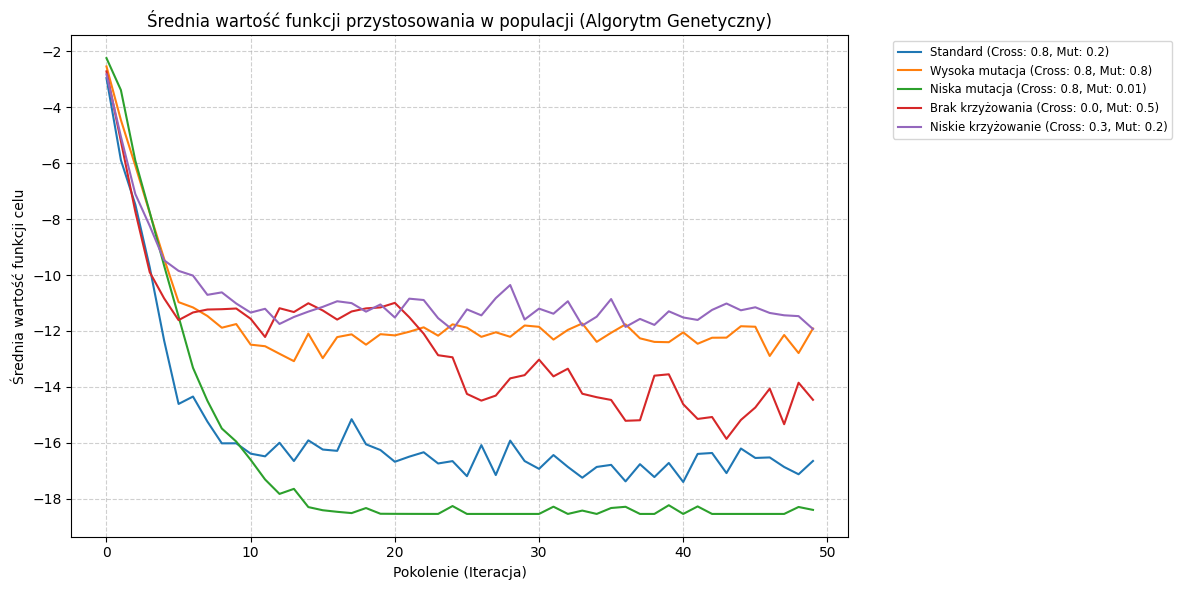

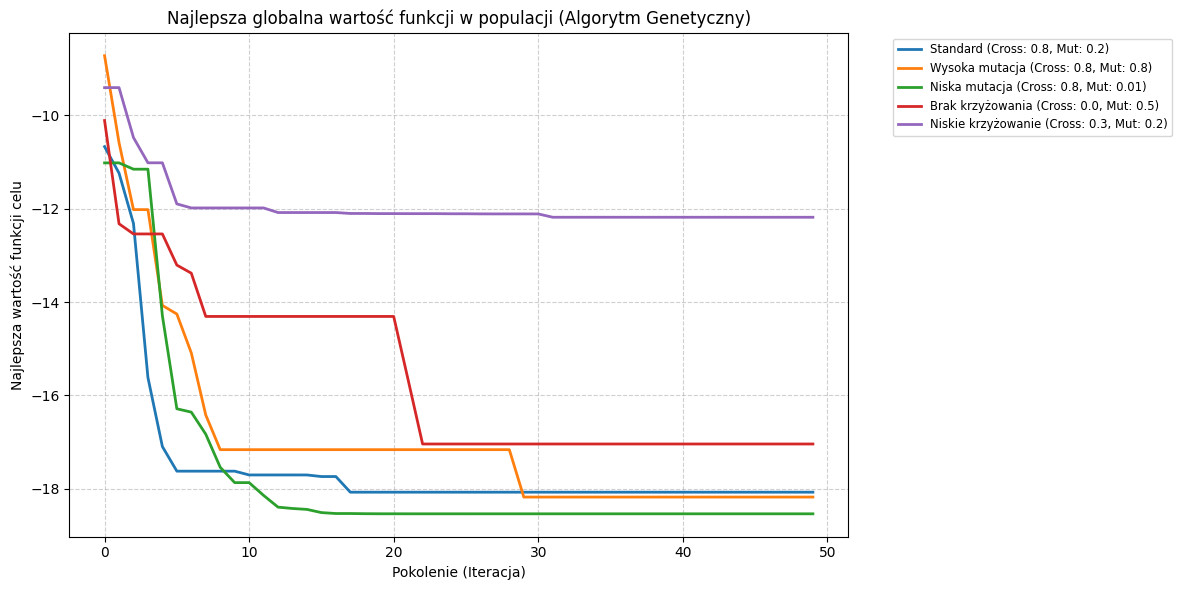

In [3]:
import time

configs = [
    {"name": "Standard (Cross: 0.8, Mut: 0.2)", "cross_rate": 0.8, "mut_rate": 0.2},
    {"name": "Wysoka mutacja (Cross: 0.8, Mut: 0.8)", "cross_rate": 0.8, "mut_rate": 0.8},
    {"name": "Niska mutacja (Cross: 0.8, Mut: 0.01)", "cross_rate": 0.8, "mut_rate": 0.01},
    {"name": "Brak krzyżowania (Cross: 0.0, Mut: 0.5)", "cross_rate": 0.0, "mut_rate": 0.5},
    {"name": "Niskie krzyżowanie (Cross: 0.3, Mut: 0.2)", "cross_rate": 0.3, "mut_rate": 0.2}
]

# Kontenery na wyniki statystyczne i przykładowe przebiegi
results_stats = {}
sample_plots_data = {}

np.random.seed(42) # Replicability seed
num_runs = 10

print(f"{'Konfiguracja GA':<40} | {'Średnia wartość':<15} | {'Odchylenie std':<15} | {'Średni czas (s)':<15}")
print("-" * 92)

for config in configs:
    run_fitnesses = []
    run_times = []
    last_histories = None

    for run in range(num_runs):
        ga = GeneticAlgorithm(
            cost_func=target_function,
            cross_rate=config["cross_rate"],
            mut_rate=config["mut_rate"]
        )

        # Start timer
        start_time = time.perf_counter()
        best_pos, best_fit, final_pop, avgs, bests_fit = ga.run()
        # End timer
        end_time = time.perf_counter()

        run_fitnesses.append(best_fit)
        run_times.append(end_time - start_time)

        if run == num_runs - 1:
            last_histories = (avgs, bests_fit, best_pos, best_fit, final_pop)

    mean_res = np.mean(run_fitnesses)
    std_res = np.std(run_fitnesses)
    mean_time = np.mean(run_times)

    results_stats[config["name"]] = {"mean": mean_res, "std": std_res, "time": mean_time}
    sample_plots_data[config["name"]] = last_histories

    print(f"{config['name']:<40} | {mean_res:<15.4f} | {std_res:<15.4f} | {mean_time:<15.6f}")

# Wykresy 2D
plt.figure(figsize=(12, 6))
for name, data in sample_plots_data.items():
    plt.plot(data[0], label=name, linewidth=1.5)

plt.title("Średnia wartość funkcji przystosowania w populacji (Algorytm Genetyczny)")
plt.xlabel("Pokolenie (Iteracja)")
plt.ylabel("Średnia wartość funkcji celu")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
for name, data in sample_plots_data.items():
    plt.plot(data[1], label=name, linewidth=2)

plt.title("Najlepsza globalna wartość funkcji w populacji (Algorytm Genetyczny)")
plt.xlabel("Pokolenie (Iteracja)")
plt.ylabel("Najlepsza wartość funkcji celu")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()